<a href="https://colab.research.google.com/github/dima-kan/ITStep-AI/blob/superwised_learning/DZ_Overfitting1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/customer_spending.csv")

In [4]:
df.head()

,annual_income,account_tenure_days,age,engagement_score,support_tickets,annual_spending
0,57964.98,1170,65,35.95,5,218.46
1,27667.36,856,58,14.56,2,16.51
2,74068.69,1178,31,33.26,2,240.06
3,82232.89,741,33,87.93,2,242.77
4,16763.02,497,31,10.22,0,130.61


# Опис даних

Цу дані користувачів онлайн-сервісу **Shoply** — сайту, де люди купують товари та оформлюють підписки. Для кожного користувача зібрана інформація про його активність, дохід та взаємодію із сайтом.

* **annual_income** — скільки грошей користувач заробляє за рік
* **account_tenure_days** — скільки днів користувач зареєстрований на сайті
* **age** — вік користувача
* **engagement_score** — наскільки активно користувач користується сайтом
* **support_tickets** — скільки разів користувач звертався до служби підтримки
* **annual_spending** — скільки грошей користувач витрачає на сайті за рік


Потрібно спрогнозувати **витрати** користувача

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [5]:

X = df.drop(columns=["annual_spending"])
y = df["annual_spending"]
y

,annual_spending
0,218.46
1,16.51
2,240.06
3,242.77
4,130.61
...,...
6515,141.48
6516,115.99
6517,75.06
6518,85.78


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [7]:

from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте витрати користувача для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [8]:
y_pred = model.predict(X_test)
y_pred[:10]


array([162.56, 116.4 , 133.23, 120.26,  10.96, 127.27, 212.47,  35.98,
       151.79, 196.01])

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [14]:
mae

32.97090490797546

In [15]:
mse

1731.1909924846627

In [16]:
r2

0.5090222257421441

# Завдання 5
Спронозуйте витрати користувача для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [17]:
y_train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

metrics_comparison = pd.DataFrame({
    "Вибірка": ["Тренувальна", "Тестова"],
    "MAE": [train_mae, test_mae],
    "R2": [train_r2, test_r2],

})

metrics_comparison


,Вибірка,MAE,R2
0,Тренувальна,0.000000,1.000000
1,Тестова,32.970905,0.509022


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [18]:
max_depths = range(2, 16)
train_mae = []
test_mae = []
for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_pred = tree.predict(X_train)
  test_pred = tree.predict(X_test)

  train_mae.append(mean_absolute_error(y_train, train_pred))
  test_mae.append(mean_absolute_error(y_test, test_pred))

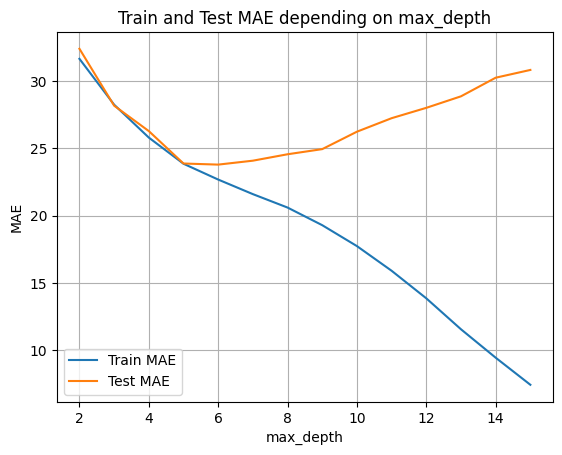

In [19]:
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [ ]:
6